In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

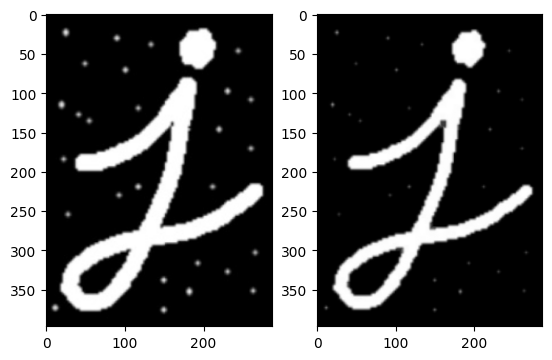

In [6]:
src = cv2.imread("images/morph_dot.jpg", 0)

mask_size = 5
padding = mask_size // 2

H = src.shape[0]
W = src.shape[1]

dst = np.zeros_like(src).astype(np.uint8)


for h in range(padding, H - padding):
    for w in range(padding, W-padding):
        roi = src[h-padding : h-padding + mask_size , w-padding : w-padding + mask_size]
        dst[h][w] = np.min(roi)


plt.subplot(1,2,1)
plt.imshow(src, cmap = 'gray')
plt.subplot(1,2,2)
plt.imshow(dst , cmap = 'gray')
plt.show()

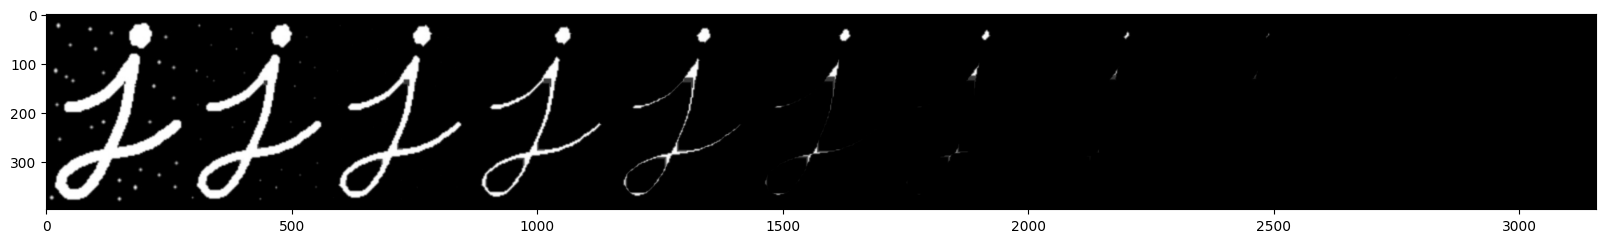

In [12]:
def eroision_dilation(img, mask_size, type):
    H = img.shape[0]
    W = img.shape[1]

    padding = mask_size // 2

    dst = np.zeros_like(img).astype(np.uint8)

    for h in range(padding , H - padding):
        for w in range(padding, W - padding):
            roi = img[h-padding : h - padding + mask_size,
                      w - padding : w - padding + mask_size]
            if type == 'eroision':
                dst[h][w] = np.min(roi)
            elif type == 'dilation':
                dst[h][w] = np.max(roi)
    
    return dst

def open_close(img, mask_size, type):

    

    if type == 'open':
        dst = eroision_dilation(img, mask_size, 'eroision')
        dst = eroision_dilation(dst, mask_size, 'dilation')
    elif type == 'close':
        dst = eroision_dilation(img, mask_size, 'dilation')
        dst = eroision_dilation(dst, mask_size, 'eroision')
    
    return dst


src = cv2.imread("images/morph_dot.jpg" , 0)
results = [src]

repeat = 10
mask_size = 5

for i in range(repeat):
    dst = eroision_dilation(src, mask_size , 'eroision')
    results.append(dst)
    src = dst
    

result = np.hstack(results)
plt.figure(figsize=(20,5))
plt.imshow(result, cmap= 'gray')
plt.show()

    
                
            